In [29]:
!pip install numpy


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

In [2]:
#Load the datasets
accident = pd.read_csv('accident.csv')
person = pd.read_csv('person.csv')
vehicle = pd.read_csv('vehicle.csv')
accident_location = pd.read_csv('accident_location.csv')

In [3]:
#Merge the datasets
accident_table = accident.merge(accident_location, on='ACCIDENT_NO', how='left')
accident_table = accident_table.merge(person, on='ACCIDENT_NO', how='right')
accident_table = accident_table.merge(vehicle, on='ACCIDENT_NO', how='left')

In [4]:
#Drop the columns that are not needed for the analysis
accident_table.drop(columns=['VEHICLE_POWER', 'VEHICLE_WEIGHT', 'CARRY_CAPACITY', 'CUBIC_CAPACITY'], inplace=True)
# Ensure date columns are properly parsed into datetime objects
accident_table['ACCIDENT_DATE'] = pd.to_datetime(accident_table['ACCIDENT_DATE'])

# Create helpful time columns for later analysis
accident_table['YEAR'] = accident_table['ACCIDENT_DATE'].dt.year
accident_table['MONTH'] = accident_table['ACCIDENT_DATE'].dt.month
display(accident_table.head(3))

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,...,VEHICLE_COLOUR_2,CAUGHT_FIRE,INITIAL_IMPACT,LAMPS,LEVEL_OF_DAMAGE,TOWED_AWAY_FLAG,TRAFFIC_CONTROL,TRAFFIC_CONTROL_DESC,YEAR,MONTH
0,T20120000012,2012-01-01,02:00:00,1,Collision with vehicle,1,Sunday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),3,...,ZZ,2.0,1,1.0,2.0,2.0,1.0,Stop-go lights,2012,1
1,T20120000012,2012-01-01,02:00:00,1,Collision with vehicle,1,Sunday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),3,...,ZZ,2.0,5,9.0,4.0,1.0,1.0,Stop-go lights,2012,1
2,T20120000012,2012-01-01,02:00:00,1,Collision with vehicle,1,Sunday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),3,...,ZZ,2.0,1,1.0,2.0,2.0,1.0,Stop-go lights,2012,1


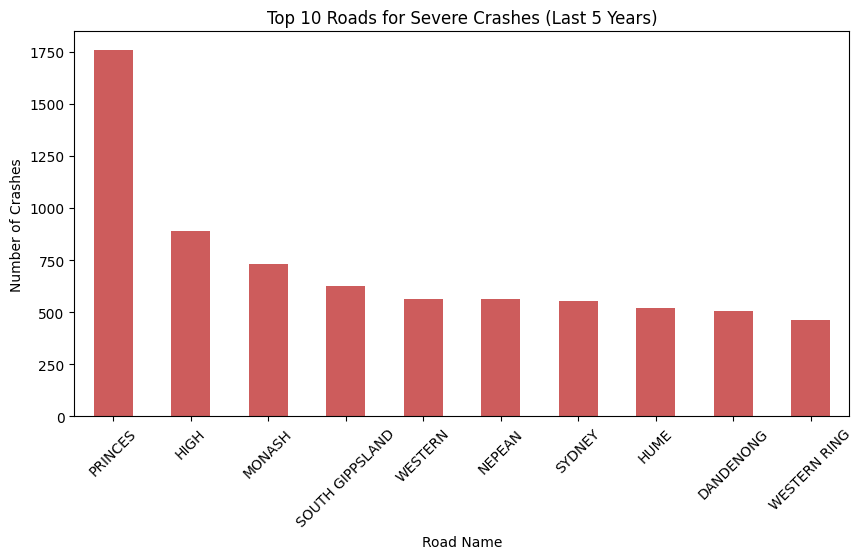

In [5]:
#Question 1: Top 10 Hazardous Crash Hotspots
# 1. Filter for the last 5 years
recent_year = accident_table['YEAR'].max()
recent_crashes = accident_table[accident_table['YEAR'] >= (recent_year - 4)]

# 2. Filter for severe crashes (Severity Codes: 3 = Fatal, 2 = Serious injury)
severe_crashes = recent_crashes[recent_crashes['SEVERITY'].isin([2, 3])]

# 3. Drop duplicates so we only count each physical crash once
unique_severe_crashes = severe_crashes.drop_duplicates(subset=['ACCIDENT_NO'])

# Plotting the Top 10 Hazardous Roads (using ROAD_NAME since LGA is unavailable)
top_10_roads = unique_severe_crashes['ROAD_NAME'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_10_roads.plot(kind='bar', color='indianred')
plt.title('Top 10 Roads for Severe Crashes (Last 5 Years)')
plt.ylabel('Number of Crashes')
plt.xlabel('Road Name')
plt.xticks(rotation=45)
plt.show()



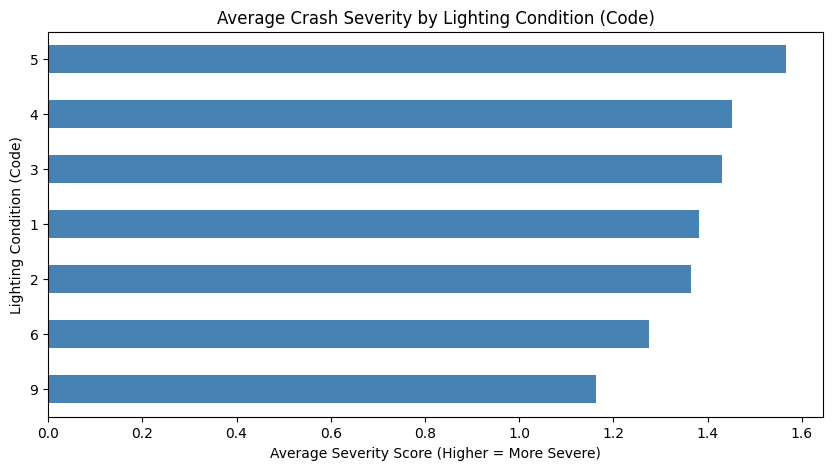

In [6]:
#Question 2: Average Crash Severity by Lighting Condition
unique_crashes = accident_table.drop_duplicates(subset=['ACCIDENT_NO'])

# Map numeric severity (1=Fatal, 2=Serious, 3=Other, 4=Non-injury) to a score for averaging (higher is worse)
severity_scores = {
    1: 3,  # Fatal
    2: 2,  # Serious
    3: 1,  # Other
    4: 0   # Non injury
}
unique_crashes['SEVERITY_SCORE'] = unique_crashes['SEVERITY'].map(severity_scores)

# Calculate average severity for each lighting condition
light_scores = unique_crashes.groupby('LIGHT_CONDITION')['SEVERITY_SCORE'].mean().sort_values()

# Plot the results
plt.figure(figsize=(10, 5))
light_scores.plot(kind='barh', color='steelblue')
plt.title('Average Crash Severity by Lighting Condition (Code)')
plt.xlabel('Average Severity Score (Higher = More Severe)')
plt.ylabel('Lighting Condition (Code)')
plt.show()

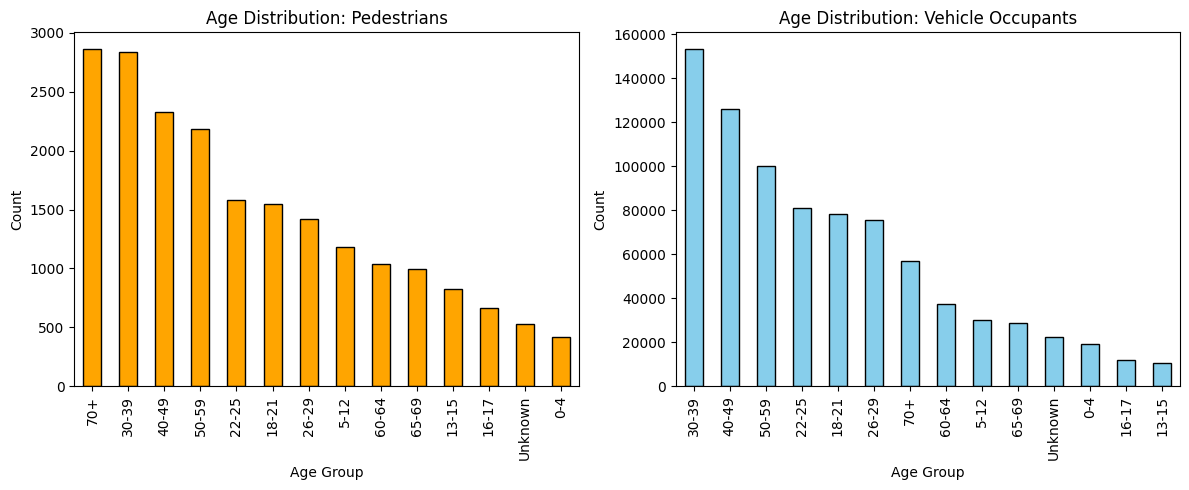

In [9]:
#Question 3: Age Distribution of Pedestrians vs Vehicle Occupants in accidents

# Filter out missing ages using the existing AGE_GROUP column
demo_df = accident_table.dropna(subset=['AGE_GROUP'])

# Separate into pedestrians and vehicle occupants using ROAD_USER_TYPE_DESC
pedestrians = demo_df[demo_df['ROAD_USER_TYPE_DESC'] == 'Pedestrians']
vehicles = demo_df[demo_df['ROAD_USER_TYPE_DESC'].isin(['Drivers', 'Passengers'])]

# Create a simple side-by-side bar chart
plt.figure(figsize=(12, 5))

# Pedestrian Plot
plt.subplot(1, 2, 1)
pedestrians['AGE_GROUP'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Age Distribution: Pedestrians')
plt.xlabel('Age Group')
plt.ylabel('Count')

# Vehicle Occupant Plot
plt.subplot(1, 2, 2)
vehicles['AGE_GROUP'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Age Distribution: Vehicle Occupants')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

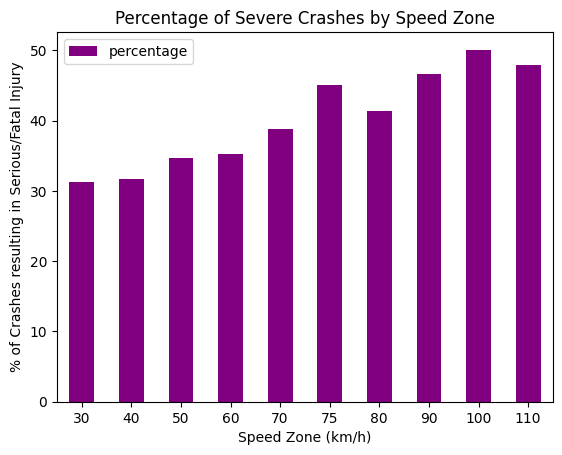

In [22]:
#Question 4: Percentage of Severe Crashes by Speed Zone
unique_crashes = accident_table.drop_duplicates(subset=['ACCIDENT_NO'])

# Find total number of crashes per speed zone
total_crashes_by_speed = unique_crashes['SPEED_ZONE'].value_counts()

# Find number of SEVERE crashes per speed zone (Codes 1 and 2)
severe_only = unique_crashes[unique_crashes['SEVERITY'].isin([1, 2])]
severe_crashes_by_speed = severe_only['SPEED_ZONE'].value_counts()

# Calculate percentage of severe crashes
percentage_severe = pd.DataFrame()
percentage_severe['percentage'] = round((severe_crashes_by_speed/ total_crashes_by_speed) * 100,2)
percentage_severe = percentage_severe[percentage_severe.index <= 110]

# Plot the results
plt.figure(figsize=(10, 5))
percentage_severe.plot(kind='bar', color='purple')
plt.title('Percentage of Severe Crashes by Speed Zone')
plt.xlabel('Speed Zone (km/h)')
plt.ylabel('% of Crashes resulting in Serious/Fatal Injury')
plt.xticks(rotation=0)
plt.show()

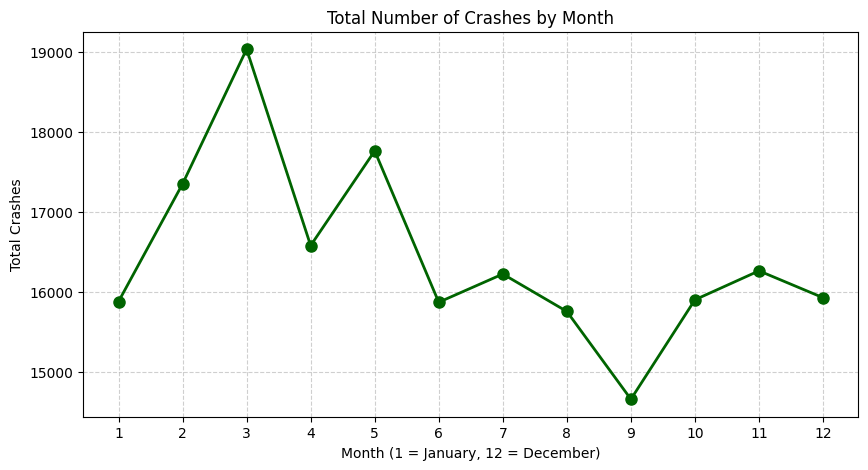

In [24]:
#Question 5 Total Number of Crashes by Month
unique_crashes = accident_table.drop_duplicates(subset=['ACCIDENT_NO'])

# Count total crashes per month
monthly_crashes = unique_crashes['MONTH'].value_counts().sort_index()

# Plot line chart
plt.figure(figsize=(10, 5))
monthly_crashes.plot(kind='line', marker='o', color='darkgreen', linewidth=2, markersize=8)
plt.title('Total Number of Crashes by Month')
plt.xlabel('Month (1 = January, 12 = December)')
plt.ylabel('Total Crashes')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
#Deep Dive Questions

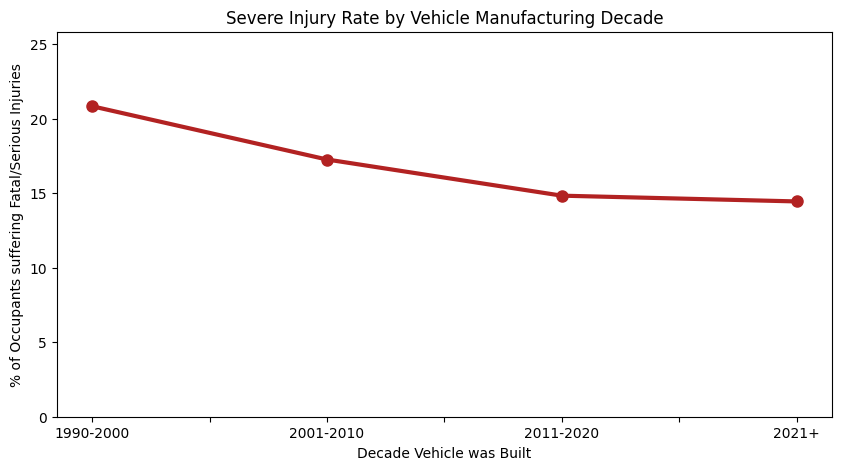

In [26]:
#Q1: How does the manufacturing year of a vehicle correlate with the injury severity?

# Merge person and vehicle on BOTH accident number and vehicle ID to match occupants to their specific car
veh_person = pd.merge(person, vehicle, on=['ACCIDENT_NO', 'VEHICLE_ID'], how='inner')

# Clean up vehicle years (remove 0s or obvious errors)
valid_years = veh_person[(veh_person['VEHICLE_YEAR_MANUF'] > 1990) & (veh_person['VEHICLE_YEAR_MANUF'] <= 2025)]

# Group into decades for easier reading
bins = [1990, 2000, 2010, 2020, 2030]
labels = ['1990-2000', '2001-2010', '2011-2020', '2021+']
valid_years['DECADE_BUILT'] = pd.cut(valid_years['VEHICLE_YEAR_MANUF'], bins=bins, labels=labels)

# Calculate the total occupants and severe injuries (Codes 1=Fatal, 2=Serious) per decade
total_occupants = valid_years['DECADE_BUILT'].value_counts()
severe_injuries = valid_years[valid_years['INJ_LEVEL'].isin([1, 2])]['DECADE_BUILT'].value_counts()

# Calculate risk percentage
survival_risk = (severe_injuries / total_occupants) * 100

plt.figure(figsize=(10, 5))
survival_risk.sort_index().plot(kind='line', marker='o', color='firebrick', linewidth=3, markersize=8)
plt.title('Severe Injury Rate by Vehicle Manufacturing Decade')
plt.xlabel('Decade Vehicle was Built')
plt.ylabel('% of Occupants suffering Fatal/Serious Injuries')
plt.ylim(0, survival_risk.max() + 5)
plt.show()

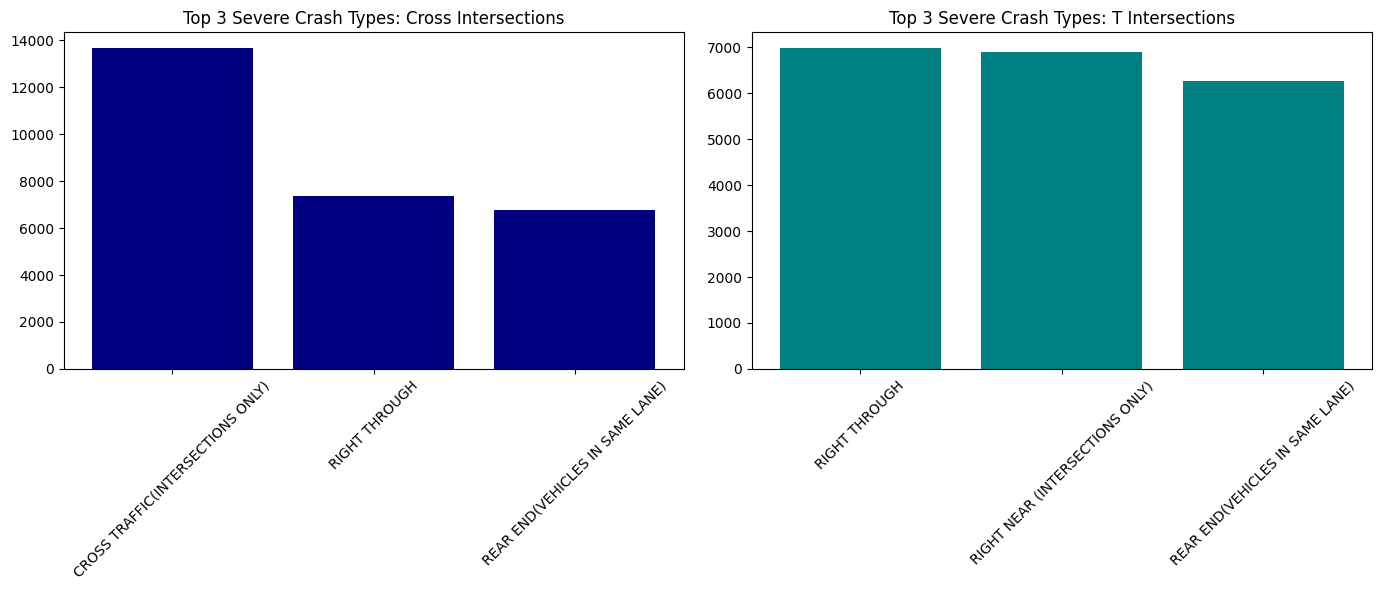

In [27]:
#Q2: What are the most frequent crash mechanisms at different types of intersections?

# Filter for only severe crashes to see what causes the most harm
severe_accidents = accident[accident['SEVERITY'].isin([2, 3])]

# Focus on the two main intersection types
intersections = severe_accidents[severe_accidents['ROAD_GEOMETRY_DESC'].isin(['Cross intersection', 'T intersection'])]

# Group by Geometry and DCA (Crash Mechanism)
dca_breakdown = intersections.groupby(['ROAD_GEOMETRY_DESC', 'DCA_DESC']).size().reset_index(name='COUNT')

# Get Top 3 mechanisms for Cross Intersections
cross_top = dca_breakdown[dca_breakdown['ROAD_GEOMETRY_DESC'] == 'Cross intersection'].nlargest(3, 'COUNT')
# Get Top 3 mechanisms for T Intersections
t_top = dca_breakdown[dca_breakdown['ROAD_GEOMETRY_DESC'] == 'T intersection'].nlargest(3, 'COUNT')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(cross_top['DCA_DESC'], cross_top['COUNT'], color='navy')
axes[0].set_title('Top 3 Severe Crash Types: Cross Intersections')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(t_top['DCA_DESC'], t_top['COUNT'], color='teal')
axes[1].set_title('Top 3 Severe Crash Types: T Intersections')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

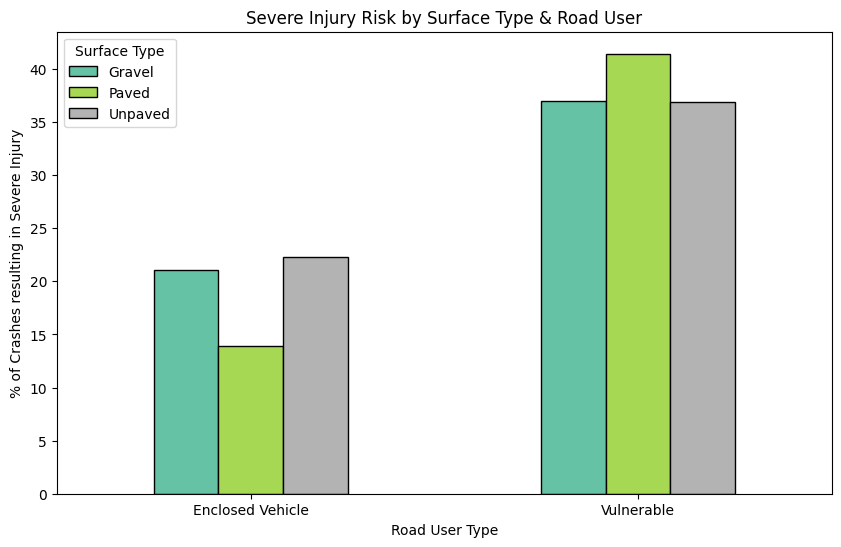

In [31]:
#Q3: How do adverse road surface conditions impact vulnerable road users?

# Merge person to vehicle to get the road surface they crashed on
# Using left merge from vehicle to person
veh_person = pd.merge(vehicle, person, on=['ACCIDENT_NO', 'VEHICLE_ID'], how='left')

# Categorize users
vulnerable_types = ['Motorcyclists', 'Bicyclists', 'E-scooter Rider']
veh_person['USER_CATEGORY'] = np.where(veh_person['ROAD_USER_TYPE_DESC'].isin(vulnerable_types), 'Vulnerable', 'Enclosed Vehicle')

# Focus on main surface types
main_surfaces = ['Paved', 'Gravel', 'Unpaved']
surface_data = veh_person[veh_person['ROAD_SURFACE_TYPE_DESC'].isin(main_surfaces)]

# Calculate Total vs Severe (Inj code 1,2) for these groups
total_by_group = surface_data.groupby(['USER_CATEGORY', 'ROAD_SURFACE_TYPE_DESC']).size()
severe_by_group = surface_data[surface_data['INJ_LEVEL'].isin([1, 2])].groupby(['USER_CATEGORY', 'ROAD_SURFACE_TYPE_DESC']).size()

# Get percentage
risk_matrix = (severe_by_group / total_by_group * 100).unstack()

risk_matrix.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Severe Injury Risk by Surface Type & Road User')
plt.ylabel('% of Crashes resulting in Severe Injury')
plt.xlabel('Road User Type')
plt.xticks(rotation=0)
plt.legend(title='Surface Type')
plt.show()

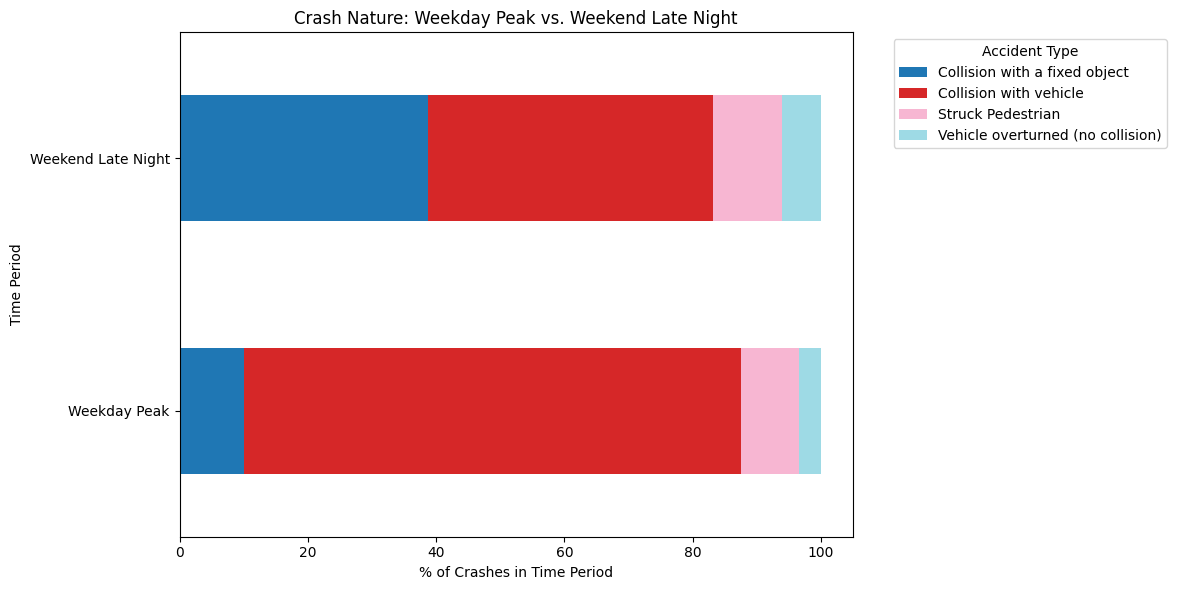

In [33]:
# Q4: How does the nature of crashes differ between Weekday Peak and Weekend Late Nights?

# Parse date and extract time features safely
accident['ACCIDENT_DATE'] = pd.to_datetime(accident['ACCIDENT_DATE'])
accident['HOUR'] = pd.to_datetime(accident['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce').dt.hour

# Define Time Periods using basic filtering
# Weekday Peak: Mon-Fri (Days 2-6 in Data.Vic usually, or rely on string description), Hours 7-9 & 15-18
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekend_days = ['Friday', 'Saturday', 'Sunday'] # Friday night counts as weekend night

is_peak = (accident['DAY_WEEK_DESC'].isin(weekday_days)) & (accident['HOUR'].isin([7, 8, 9, 15, 16, 17, 18]))
is_late_night = (accident['DAY_WEEK_DESC'].isin(weekend_days)) & (accident['HOUR'].isin([22, 23, 0, 1, 2, 3, 4]))

accident.loc[is_peak, 'TIME_PERIOD'] = 'Weekday Peak'
accident.loc[is_late_night, 'TIME_PERIOD'] = 'Weekend Late Night'

time_analysis = accident.dropna(subset=['TIME_PERIOD'])

# Compare Accident Types (e.g., Multi-vehicle vs Single-vehicle into fixed object)
# Get the top 4 accident types overall to keep the chart clean
top_acc_types = time_analysis['ACCIDENT_TYPE_DESC'].value_counts().nlargest(4).index
time_analysis = time_analysis[time_analysis['ACCIDENT_TYPE_DESC'].isin(top_acc_types)]

# Calculate percentages within their respective time periods
period_counts = time_analysis.groupby(['TIME_PERIOD', 'ACCIDENT_TYPE_DESC']).size().unstack()
period_percentages = period_counts.div(period_counts.sum(axis=1), axis=0) * 100

period_percentages.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Crash Nature: Weekday Peak vs. Weekend Late Night')
plt.xlabel('% of Crashes in Time Period')
plt.ylabel('Time Period')
plt.legend(title='Accident Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

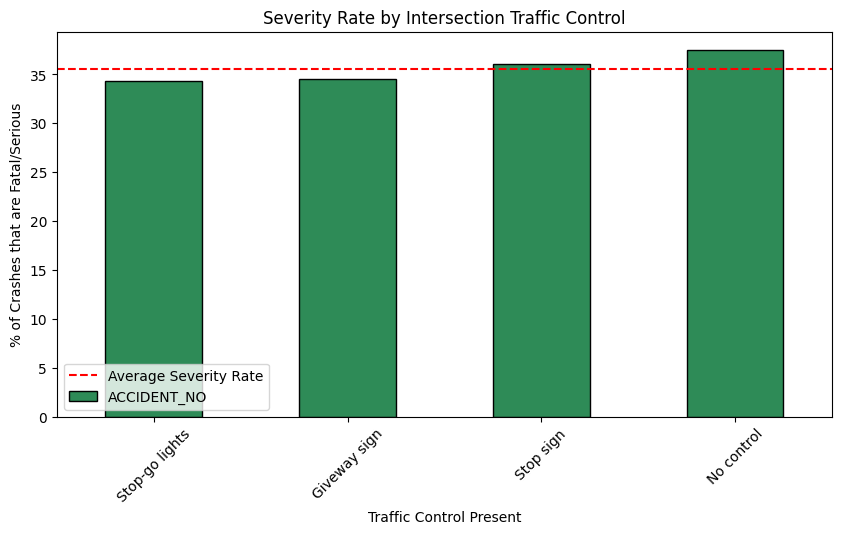

In [34]:
#Q5: How do different traffic control mechanisms compare in preventing severe crashes?

# Merge accident and vehicle to get the traffic control present at the crash
acc_veh = pd.merge(accident, vehicle, on='ACCIDENT_NO', how='inner')

# Filter to intersections only
intersections_only = acc_veh[acc_veh['ROAD_GEOMETRY_DESC'].isin(['Cross intersection', 'T intersection', 'Multiple intersection'])]

# Filter to main traffic controls
main_controls = ['Stop-go lights', 'Stop sign', 'Giveway sign', 'No control']
control_data = intersections_only[intersections_only['TRAFFIC_CONTROL_DESC'].isin(main_controls)]

# Calculate total crashes vs severe crashes at these controls
total_ctrl = control_data.groupby('TRAFFIC_CONTROL_DESC')['ACCIDENT_NO'].nunique()
severe_ctrl = control_data[control_data['SEVERITY'].isin([1, 2])].groupby('TRAFFIC_CONTROL_DESC')['ACCIDENT_NO'].nunique()

# Calculate effectiveness (lower severe % = more effective)
severity_rate = (severe_ctrl / total_ctrl * 100).sort_values()

plt.figure(figsize=(10, 5))
severity_rate.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Severity Rate by Intersection Traffic Control')
plt.ylabel('% of Crashes that are Fatal/Serious')
plt.xlabel('Traffic Control Present')
plt.xticks(rotation=45)
plt.axhline(severity_rate.mean(), color='red', linestyle='--', label='Average Severity Rate')
plt.legend()
plt.show()